# 2일차 6교시 실습 · 프레임 차이와 변화 영역
강의자료 PDF 1~16페이지를 순서대로 다룹니다. 빈칸은 A·B 두 개입니다. 준비 함수와 입력 코드는 완성되어 있습니다. 같은 폴더의 data와 motion_helpers.py를 함께 사용합니다.


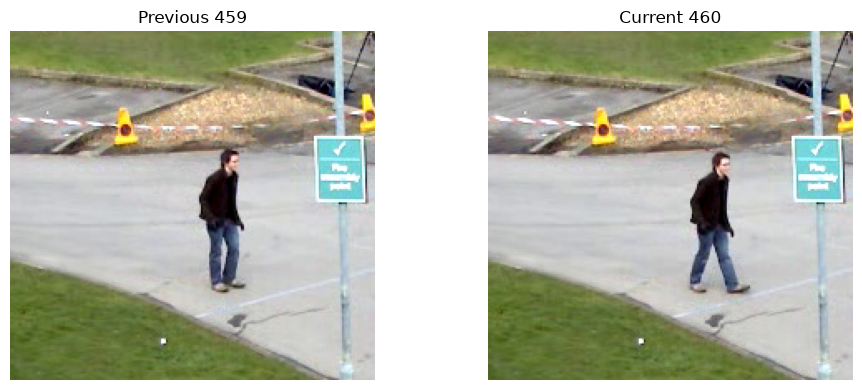

In [18]:
from pathlib import Path
import cv2
import numpy as np
from motion_helpers import read_image, gray, show, mark_changes, process_video, run_camera

data = Path("data")
prev = read_image(data / "prev.png")
current = read_image(data / "curr.png")
prev_gray = gray(prev)
current_gray = gray(current)
show([prev, current], ["Previous 459", "Current 460"])

## 같은 위치의 실제 값 · 강의자료 PDF 2페이지
좌표는 잘라낸 영상의 왼쪽 위를 원점으로 한 (x,y)입니다. 강의자료 PDF의 빨간 원은 Grayscale 변환 후 측정한 위치입니다. 값의 범위는 0~255이며 0은 검정, 255는 흰색입니다.


In [19]:
x, y = 141, 115
print("Previous:", int(prev_gray[y,x]))
print("Current:", int(current_gray[y,x]))

Previous: 225
Current: 0


## 절댓값 차이와 마스크 · 강의자료 PDF 4~5페이지
A는 강의자료 PDF 4페이지의 함수 이름, B는 강의자료 PDF 5페이지의 이진화 종류입니다. 기준값 20은 이 영상에 적용한 설정값입니다. 차이가 20과 같으면 제외합니다.


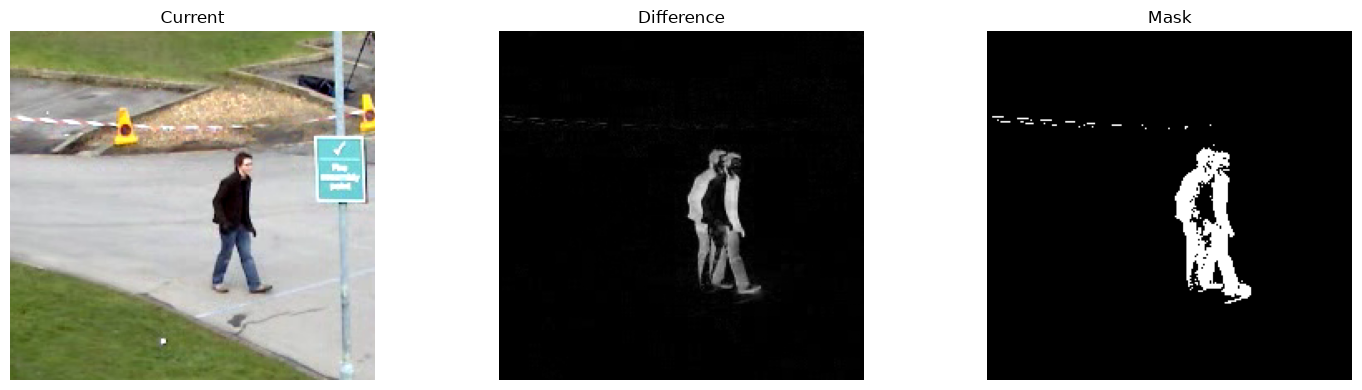

Selected pixels: 1949


In [20]:
def difference_mask(gray, prev_gray, threshold_value):
    diff = cv2.absdiff(gray, prev_gray)  # A: PPT 4
    _, mask = cv2.threshold(diff, threshold_value, 255, cv2.THRESH_BINARY)  # B: PPT 5
    return diff, mask

diff, mask = difference_mask(current_gray, prev_gray, 20)
show([current, diff, mask], ["Current", "Difference", "Mask"])
print("Selected pixels:", cv2.countNonZero(mask))

## 기준값 비교 · 강의자료 PDF 6페이지
프레임 쌍은 유지하고 기준값만 바꿉니다. 선택 픽셀 수가 많다고 검출이 더 정확한 것은 아닙니다.


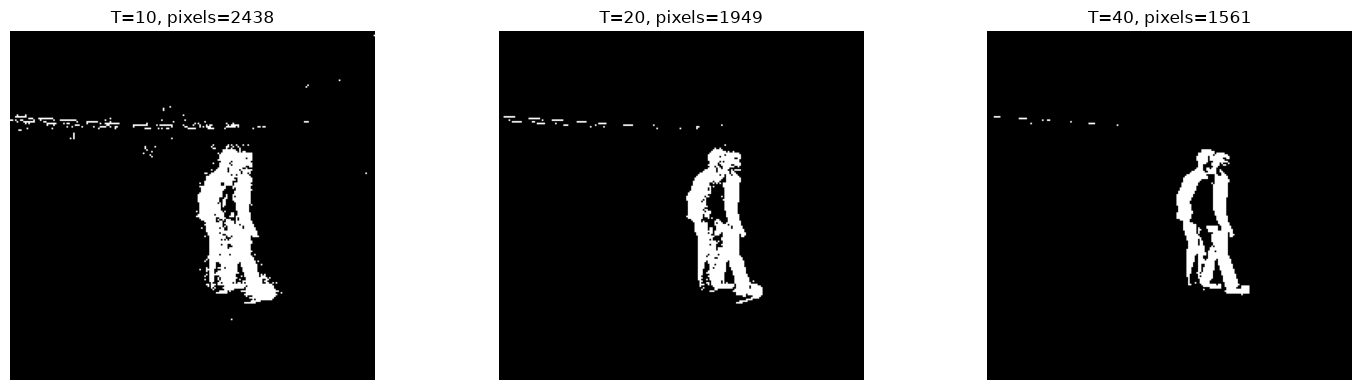

[2438, 1949, 1561]


In [21]:
thresholds = [10, 20, 40]
masks = [difference_mask(current_gray, prev_gray, value)[1] for value in thresholds]
threshold_counts = [cv2.countNonZero(m) for m in masks]
show(masks, [f"T={t}, pixels={n}" for t,n in zip(thresholds,threshold_counts)])
print(threshold_counts)

## 이전 위치와 현재 위치 · 강의자료 PDF 7페이지
동일한 구간을 확대합니다. 새로 사람이 들어온 곳뿐 아니라 사람이 떠난 곳에도 차이가 생깁니다.


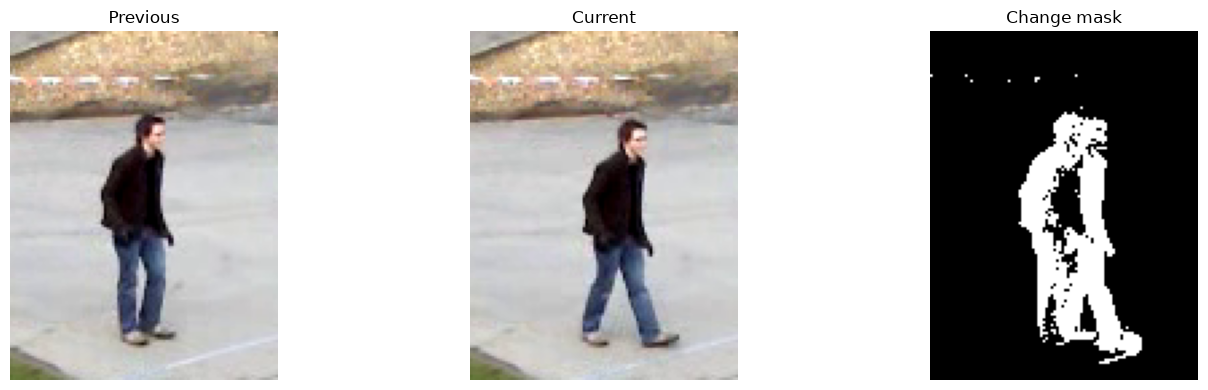

In [22]:
show([prev[40:170,80:180], current[40:170,80:180], mask[40:170,80:180]], ["Previous", "Current", "Change mask"])

## 이동·제자리·재이동 · 강의자료 PDF 9페이지
각 프레임은 직전 프레임과 비교합니다. 모두 실제 영상에서 추출했으며 정지 화면을 복제하지 않았습니다. 제자리에서도 몸의 움직임과 영상 잡음이 남을 수 있습니다.


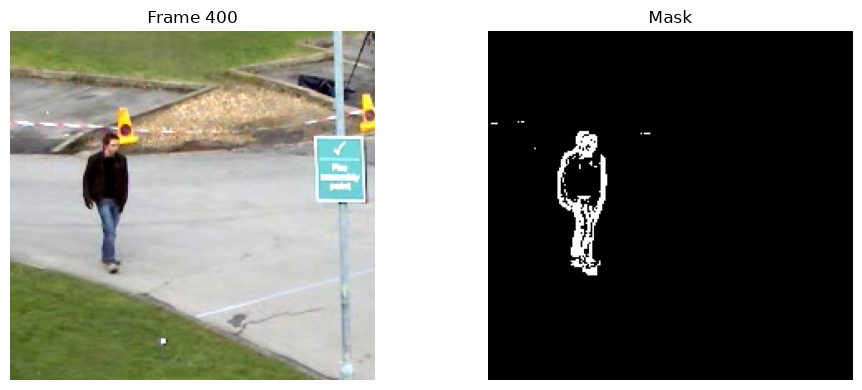

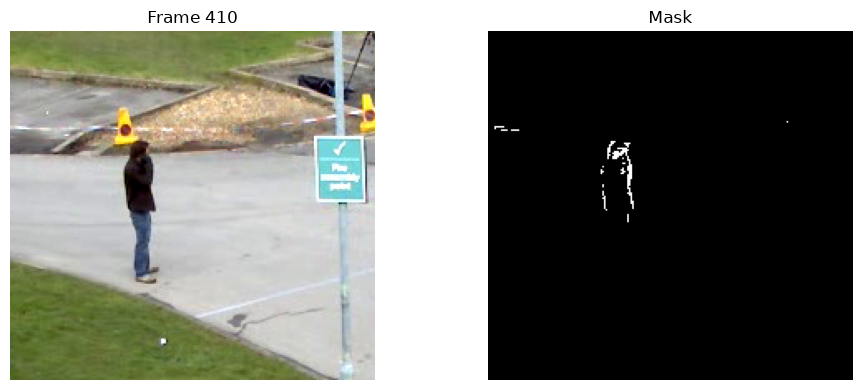

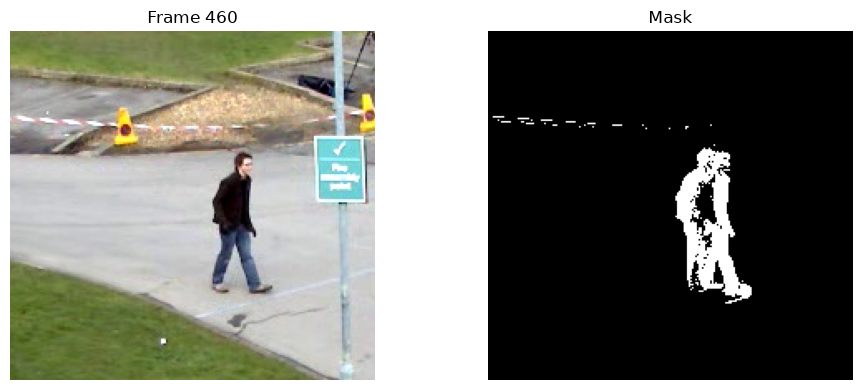

[879, 174, 1949]


In [23]:
stop_counts = []
for number in [400,410,460]:
    before = read_image(data / f"frame{number-1}.png")
    now = read_image(data / f"frame{number}.png")
    _, result_mask = difference_mask(gray(now), gray(before), 20)
    stop_counts.append(cv2.countNonZero(result_mask))
    show([now, result_mask], [f"Frame {number}", "Mask"])
print(stop_counts)

## 밝기 가공 · 강의자료 PDF 10페이지
원본 BGR 값에 각각 30을 더하고 255를 넘는 값은 제한한 사진입니다. 실제 조명 변화 촬영이 아닙니다.


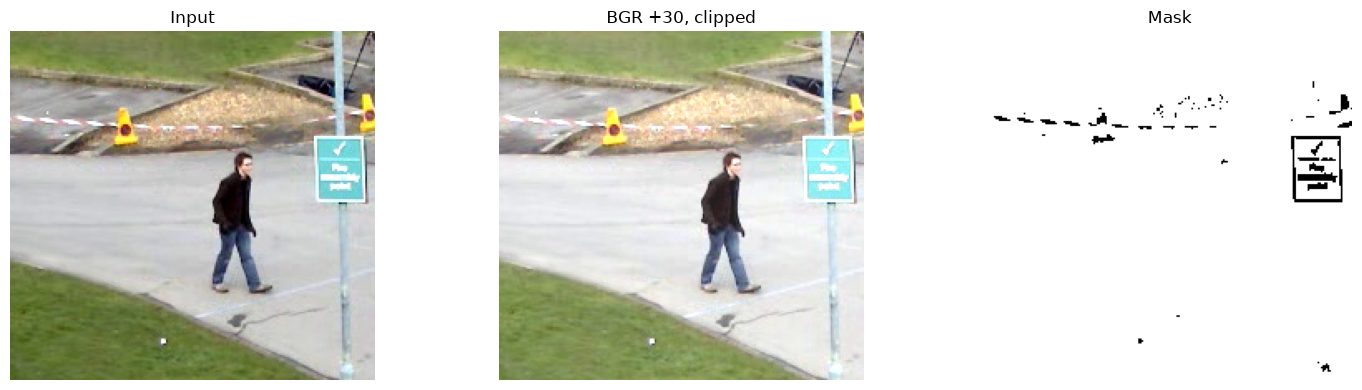

45387


In [24]:
bright = read_image(data / "bright.png")
_, bright_mask = difference_mask(gray(bright), current_gray, 20)
show([current, bright, bright_mask], ["Input", "BGR +30, clipped", "Mask"])
print(cv2.countNonZero(bright_mask))

## 위치 이동 가공 · 강의자료 PDF 11페이지
원본 전체를 오른쪽으로 4 pixel 이동한 뒤 같은 ROI를 잘랐습니다. ROI 안에는 이동으로 새로 생긴 테두리가 없습니다. 실제 카메라 이동을 촬영한 영상이 아닙니다.


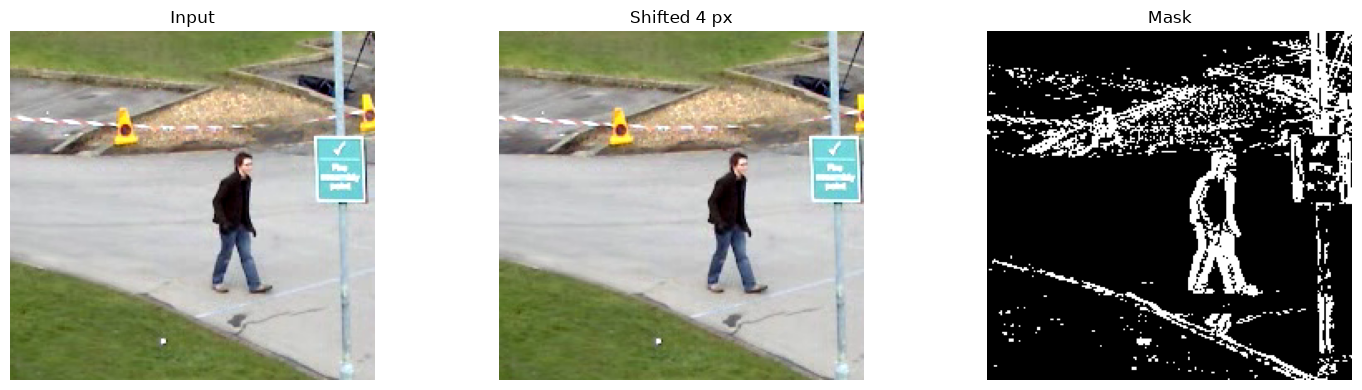

7452


In [25]:
shift = read_image(data / "shift.png")
_, shift_mask = difference_mask(gray(shift), current_gray, 20)
show([current, shift, shift_mask], ["Input", "Shifted 4 px", "Mask"])
print(cv2.countNonZero(shift_mask))

## 변화 영역 표시 · 강의자료 PDF 12페이지
제공 함수 mark_changes는 Closing 3×3 후 Contour 면적 30 pixel² 이상인 영역에 상자를 표시합니다. 상자 개수를 물체 개수로 해석하지 않습니다.


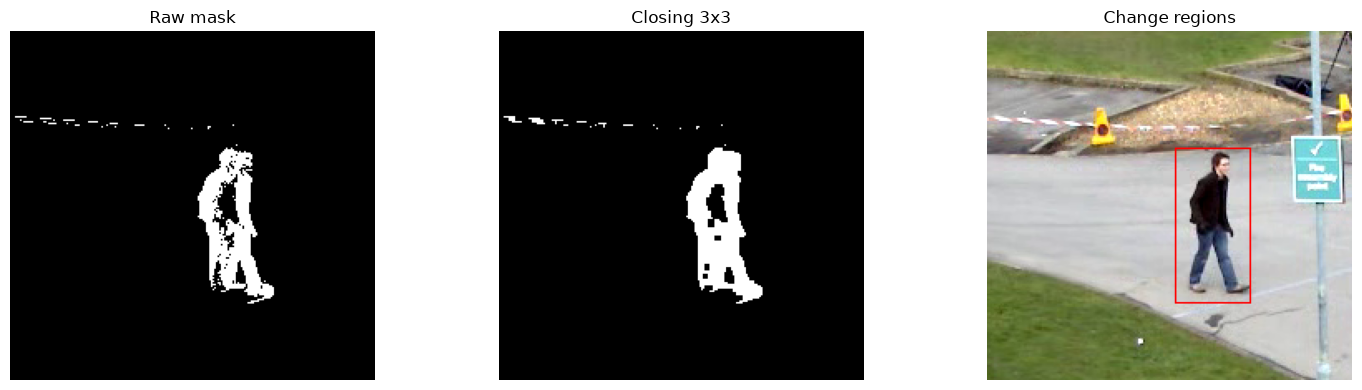

Boxes (x,y,w,h): [(113, 70, 46, 94)]


In [26]:
clean, marked, boxes = mark_changes(current, mask)
show([mask, clean, marked], ["Raw mask", "Closing 3x3", "Change regions"])
print("Boxes (x,y,w,h):", boxes)

## 색상 선택과 시간 비교 · 강의자료 PDF 13페이지
5교시와 같은 녹색 범위를 사용합니다. 차이 영상에서는 손이나 얼굴의 변화도 선택될 수 있습니다.


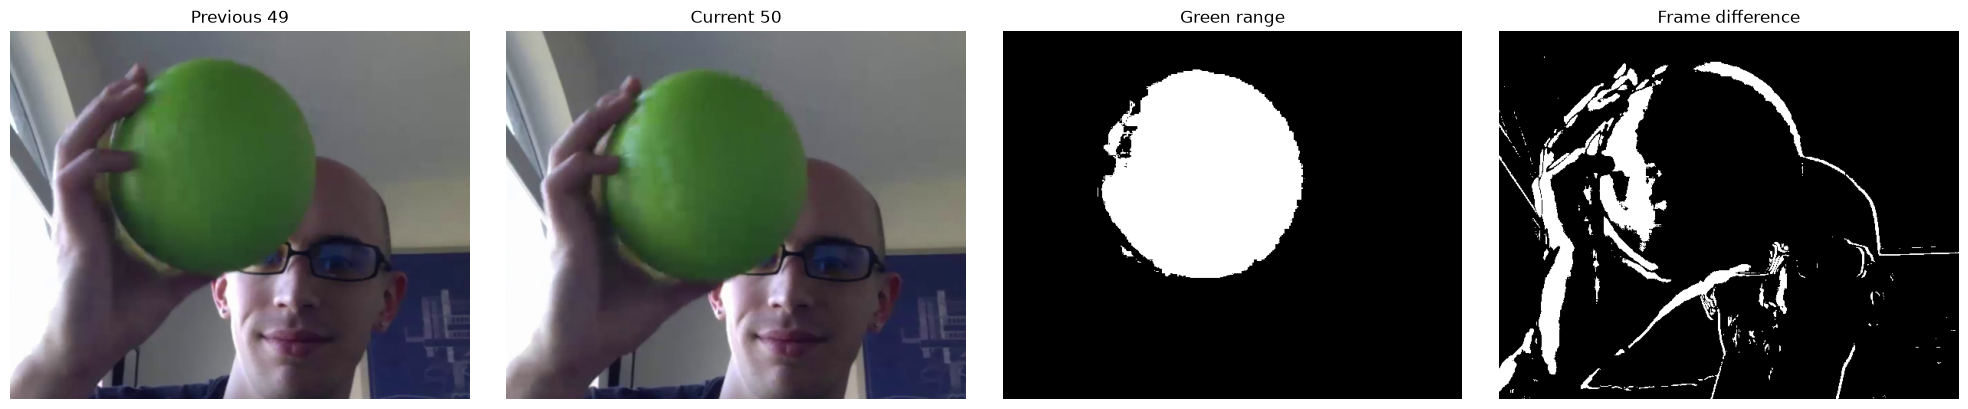

In [27]:
ball = read_image(data / "ball.png")
ball_prev = read_image(data / "ballprev.png")
hsv_mask = cv2.inRange(cv2.cvtColor(ball, cv2.COLOR_BGR2HSV), (35,80,60), (85,255,255))
_, ball_mask = difference_mask(gray(ball), gray(ball_prev), 20)
show([ball_prev, ball, hsv_mask, ball_mask], ["Previous 49", "Current 50", "Green range", "Frame difference"])

## 영상 전체에 적용 · 강의자료 PDF 8·14페이지
입력 clip.avi는 원본 Frame 350~470의 같은 ROI를 무손실로 저장한 영상입니다. 첫 프레임은 저장만 하고 120쌍을 비교합니다. outputs 폴더에 원본·차이·마스크를 나란히 저장합니다. 제공 process_video 함수가 이전 프레임을 갱신합니다. 강의자료 PDF 8페이지의 current는 이 함수 내부의 현재 Grayscale 영상입니다. None은 이전 영상이 없는 첫 상태, copy()는 배열의 복사본을 보관하는 동작입니다.


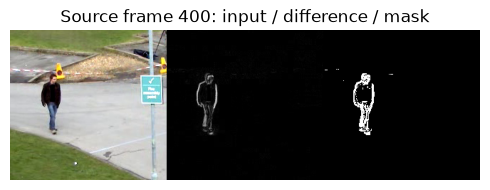

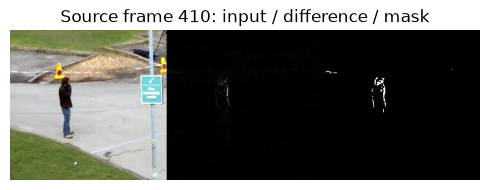

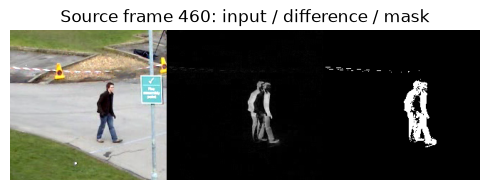

Frames: 121 Compared pairs: 120


In [28]:
frame_count, video_counts = process_video(data / "clip.avi", difference_mask, threshold_value=20)
print("Frames:", frame_count, "Compared pairs:", len(video_counts))

## 비교 간격 · 강의자료 PDF 15페이지
현재 Frame 460은 그대로 두고 459·450과 각각 비교합니다. 두 결과의 픽셀 수를 이동 속도로 해석하지 않습니다.


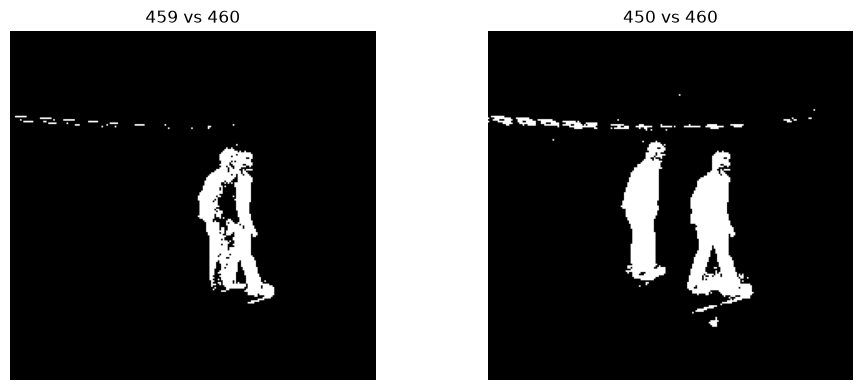

1949 3413


In [29]:
older = read_image(data / "frame450.png")
_, interval_mask = difference_mask(current_gray, gray(older), 20)
show([mask, interval_mask], ["459 vs 460", "450 vs 460"])
print(cv2.countNonZero(mask), cv2.countNonZero(interval_mask))

## 고정 배경 사진 · 강의자료 PDF 16페이지
이 비교만 ROI를 x230:370, y140:350으로 좁혔습니다. 기준 350·현재 410·직전 409 모두 같은 ROI입니다. 기준 사진에도 배경과 조명 변화가 누적될 수 있습니다.


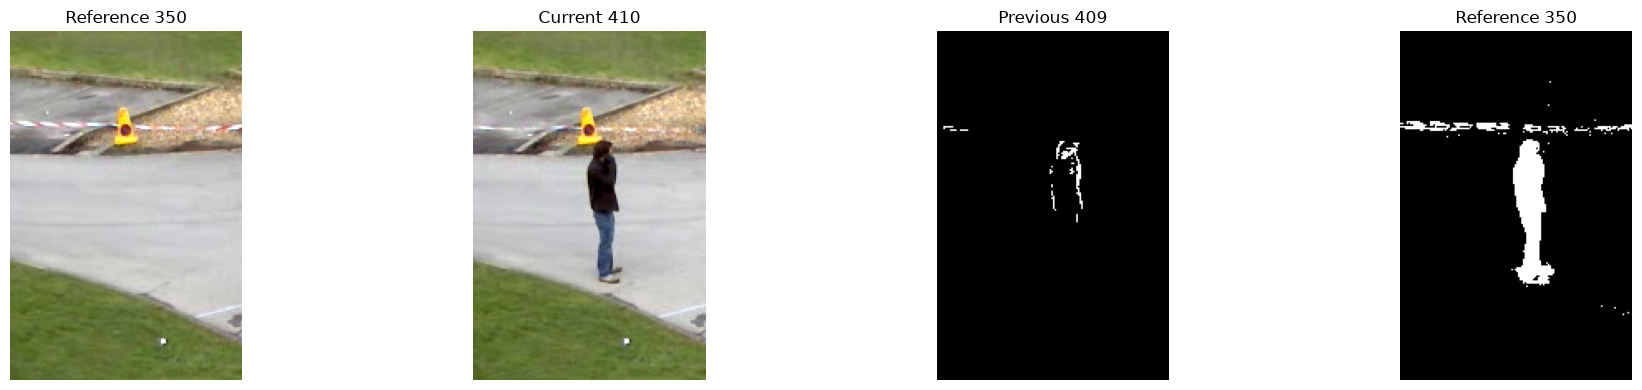

In [30]:
background = read_image(data / "bg_clean.png")
stopped = read_image(data / "bg_stopped.png")
stop_previous = read_image(data / "bg_prev.png")
_, adjacent_mask = difference_mask(gray(stopped), gray(stop_previous), 20)
_, background_mask = difference_mask(gray(stopped), gray(background), 20)
show([background, stopped, adjacent_mask, background_mask], ["Reference 350", "Current 410", "Previous 409", "Reference 350"])

## USB 카메라
로컬 Python에서 실행합니다. 아래 값을 True로 바꾸고, 영상 창에서 q를 눌러 종료합니다. 카메라를 고정하고 안정적인 조명에서 시작합니다. 해상도와 장면이 달라지므로 기준값은 결과를 보며 조절합니다.


In [ ]:
# 카메라를 가만히 있는게 하더라도, 미세한 움직임이 있기 때문에 mask 를 보면 움직임이 있는것들이 구분 된 형태인데,
# 가만히 고정시켜놓은 경우 mask 가 까만 형태로 나온다..
RUN_CAMERA = True
if RUN_CAMERA:
    run_camera(difference_mask, threshold_value=20, camera_id=2)